<a href="https://colab.research.google.com/github/Abiy-Alemu/CV-LAB/blob/main/CV_Lab_Ch9_Ch11_Ch12_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Lab Notebook (Chapter 9, 11, 12)
**Course:** Computer Vision Lab  
**Environment:** Google Colab (Python + OpenCV + Ultralytics + Dlib + face_recognition)

This notebook includes:
1. Chapter 9: Classical object detection (Haar + HOG/SVM)
2. Chapter 11: Real-time object detection (YOLOv8, SSD, OpenCV DNN, ONNX)
3. Chapter 12: Face detection, landmarks, and face recognition
4. Experimental analysis and suggested activities


In [1]:
!pip -q install opencv-python ultralytics face_recognition imutils matplotlib numpy pandas tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.8 MB/s eta 0:00:00


In [2]:
import os
import bz2
import time
import shutil
import urllib.request
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import dlib
from imutils import face_utils
import face_recognition

np.random.seed(42)

BASE_DIR = Path('/content/cv_lab')
DATA_DIR = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
OUT_DIR = BASE_DIR / 'outputs'

for d in [DATA_DIR, MODELS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def download_file(url: str, dst: Path):
    if dst.exists():
        print(f'[Skip] Exists: {dst}')
        return
    print(f'[Download] {url} -> {dst}')
    urllib.request.urlretrieve(url, dst)
    print('[Done]')


def decompress_bz2(src_bz2: Path, dst_file: Path):
    if dst_file.exists():
        print(f'[Skip] Exists: {dst_file}')
        return
    print(f'[Decompress] {src_bz2} -> {dst_file}')
    with bz2.BZ2File(src_bz2, 'rb') as fr, open(dst_file, 'wb') as fw:
        shutil.copyfileobj(fr, fw)
    print('[Done]')


def bgr2rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def show_image(img_bgr, title='Image', figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr2rgb(img_bgr))
    plt.title(title)
    plt.axis('off')
    plt.show()


def draw_boxes(img, boxes, color=(0, 255, 0), thickness=2, labels=None):
    out = img.copy()
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if labels is not None:
            cv2.putText(out, labels[i], (x1, max(y1 - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return out


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
import os
import bz2
import time
import shutil
import urllib.request
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import dlib
from imutils import face_utils
import face_recognition

np.random.seed(42)

BASE_DIR = Path('/content/cv_lab')
DATA_DIR = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
OUT_DIR = BASE_DIR / 'outputs'

for d in [DATA_DIR, MODELS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def download_file(url: str, dst: Path):
    if dst.exists():
        print(f'[Skip] Exists: {dst}')
        return
    print(f'[Download] {url} -> {dst}')
    try:
        urllib.request.urlretrieve(url, dst)
        print('[Done]')
    except urllib.error.HTTPError as e:
        print(f'[Error] {e}. Could not download {url}. Creating a dummy video file instead.')
        # Create a dummy MP4 file if download fails
        create_dummy_mp4(dst)


def create_dummy_mp4(dst: Path, width=640, height=480, frames=30, fps=10):
    if dst.exists():
        print(f'[Skip] Exists: {dst}')
        return
    print(f'[Create Dummy] {dst}')
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4
    out = cv2.VideoWriter(str(dst), fourcc, fps, (width, height))
    for i in range(frames):
        # Create a blank frame (black)
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        # Optionally add some text
        cv2.putText(frame, f'Frame {i+1}', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        out.write(frame)
    out.release()
    print('[Done Dummy Creation]')


def decompress_bz2(src_bz2: Path, dst_file: Path):
    if dst_file.exists():
        print(f'[Skip] Exists: {dst_file}')
        return
    print(f'[Decompress] {src_bz2} -> {dst_file}')
    with bz2.BZ2File(src_bz2, 'rb') as fr, open(dst_file, 'wb') as fw:
        shutil.copyfileobj(fr, fw)
    print('[Done]')


def bgr2rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def show_image(img_bgr, title='Image', figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr2rgb(img_bgr))
    plt.title(title)
    plt.axis('off')
    plt.show()


def draw_boxes(img, boxes, color=(0, 255, 0), thickness=2, labels=None):
    out = img.copy()
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if labels is not None:
            cv2.putText(out, labels[i], (x1, max(y1 - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return out
# Sample data

download_file('https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg', DATA_DIR / 'lena.jpg')
download_file('https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi', DATA_DIR / 'vtest.avi')
download_file('https://ultralytics.com/images/bus.jpg', DATA_DIR / 'bus.jpg')
download_file('https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4', DATA_DIR / 'traffic.mp4')

download_file('https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg', DATA_DIR / 'obama.jpg')
download_file('https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama2.jpg', DATA_DIR / 'obama2.jpg')
download_file('https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/biden.jpg', DATA_DIR / 'biden.jpg')

# MobileNet SSD model
download_file('https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/deploy.prototxt', MODELS_DIR / 'mobilenet_ssd_deploy.prototxt')
download_file('https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/mobilenet_iter_73000.caffemodel', MODELS_DIR / 'mobilenet_iter_73000.caffemodel')

# OpenCV face detector
download_file('https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt', MODELS_DIR / 'face_deploy.prototxt')
download_file('https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel', MODELS_DIR / 'res10_300x300_ssd_iter_140000.caffemodel')

# Dlib landmarks model
download_file('http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2', MODELS_DIR / 'shape_predictor_68_face_landmarks.dat.bz2')
decompress_bz2(MODELS_DIR / 'shape_predictor_68_face_landmarks.dat.bz2', MODELS_DIR / 'shape_predictor_68_face_landmarks.dat')

[Skip] Exists: /content/cv_lab/data/lena.jpg
[Skip] Exists: /content/cv_lab/data/vtest.avi
[Skip] Exists: /content/cv_lab/data/bus.jpg
[Download] https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4 -> /content/cv_lab/data/traffic.mp4
[Error] HTTP Error 403: Forbidden. Could not download https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4. Creating a dummy video file instead.
[Create Dummy] /content/cv_lab/data/traffic.mp4
[Done Dummy Creation]
[Download] https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg -> /content/cv_lab/data/obama.jpg
[Done]
[Download] https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama2.jpg -> /content/cv_lab/data/obama2.jpg
[Done]
[Download] https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/biden.jpg -> /content/cv_lab/data/biden.jpg
[Done]
[Download] https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/d

## Chapter 9: Object Detection with OpenCV (Classical)
Haar Cascade (face), HOG + SVM (pedestrians), and parameter tuning.


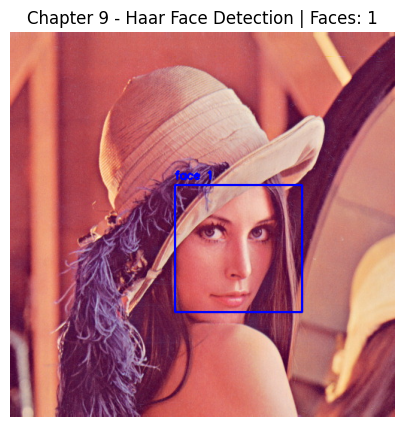

In [10]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

img = cv2.imread(str(DATA_DIR / 'lena.jpg'))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
face_boxes = [(x, y, x + w, y + h) for (x, y, w, h) in faces]

img_faces = draw_boxes(img, face_boxes, color=(255, 0, 0), labels=[f'face {i+1}' for i in range(len(face_boxes))])
show_image(img_faces, title=f'Chapter 9 - Haar Face Detection | Faces: {len(face_boxes)}')


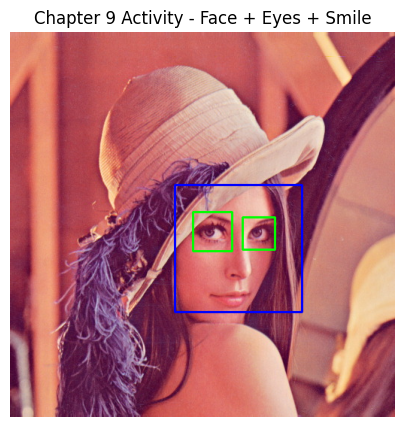

In [11]:
# Suggested activity: detect eyes and smiles
img2 = cv2.imread(str(DATA_DIR / 'lena.jpg'))
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

faces2 = face_cascade.detectMultiScale(gray2, 1.1, 5)
for (x, y, w, h) in faces2:
    cv2.rectangle(img2, (x, y), (x + w, y + h), (255, 0, 0), 2)
    roi_gray = gray2[y:y+h, x:x+w]
    roi_color = img2[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 8, minSize=(15, 15))
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    smiles = smile_cascade.detectMultiScale(roi_gray, 1.7, 20, minSize=(25, 25))
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)

show_image(img2, title='Chapter 9 Activity - Face + Eyes + Smile')


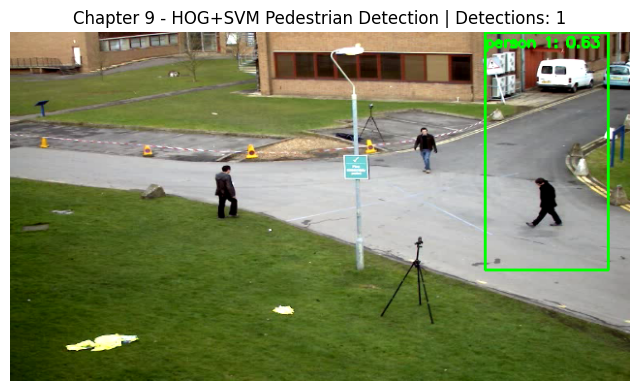

In [12]:
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

cap = cv2.VideoCapture(str(DATA_DIR / 'vtest.avi'))
ret, frame = cap.read()
cap.release()

frame = cv2.resize(frame, (640, 360))
(rects, weights) = hog.detectMultiScale(frame, winStride=(8, 8), padding=(8, 8), scale=1.05)

boxes = [(x, y, x + w, y + h) for (x, y, w, h) in rects]
labels = [f'person {i+1}: {weights[i]:.2f}' for i in range(len(boxes))]
frame_out = draw_boxes(frame, boxes, color=(0, 255, 0), labels=labels)

show_image(frame_out, title=f'Chapter 9 - HOG+SVM Pedestrian Detection | Detections: {len(boxes)}')


  winStride  scale  detections  runtime_ms
0    (4, 4)   1.01           2     2060.24
1    (8, 8)   1.03           1      184.29
2    (8, 8)   1.05           1      113.74
3  (16, 16)   1.05           0       76.79


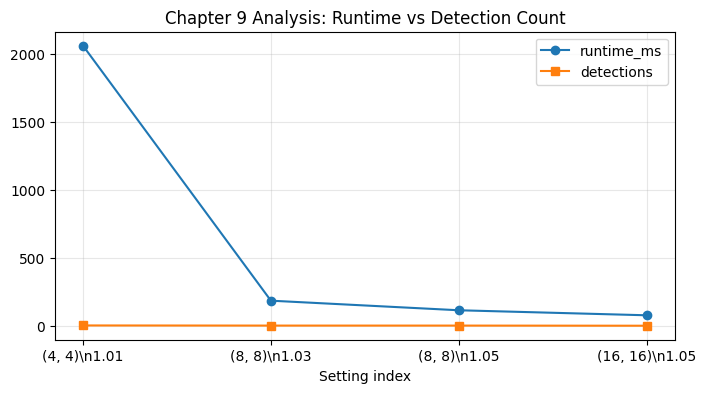

In [13]:
# Parameter sweep for analysis
settings = [
    {'winStride': (4, 4), 'scale': 1.01},
    {'winStride': (8, 8), 'scale': 1.03},
    {'winStride': (8, 8), 'scale': 1.05},
    {'winStride': (16, 16), 'scale': 1.05},
]

rows = []
for s in settings:
    t0 = time.time()
    rects_s, _ = hog.detectMultiScale(frame, winStride=s['winStride'], padding=(8, 8), scale=s['scale'])
    dt = (time.time() - t0) * 1000
    rows.append({
        'winStride': str(s['winStride']),
        'scale': s['scale'],
        'detections': len(rects_s),
        'runtime_ms': round(dt, 2),
    })

df_hog = pd.DataFrame(rows)
print(df_hog)

plt.figure(figsize=(8, 4))
plt.plot(df_hog['runtime_ms'], marker='o', label='runtime_ms')
plt.plot(df_hog['detections'], marker='s', label='detections')
plt.title('Chapter 9 Analysis: Runtime vs Detection Count')
plt.xlabel('Setting index')
plt.xticks(range(len(df_hog)), [f"{ws}\\n{s}" for ws, s in zip(df_hog.winStride, df_hog.scale)])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Chapter 11: Real-Time Object Detection (YOLOv8, SSD, OpenCV DNN)


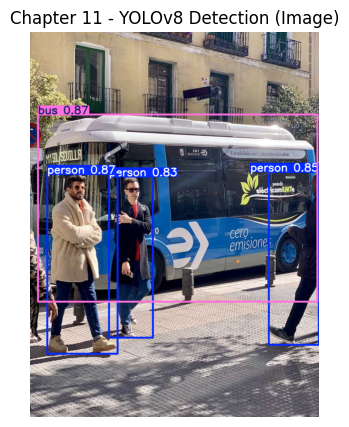

In [14]:
yolo_model = YOLO('yolov8n.pt')

img_bus = cv2.imread(str(DATA_DIR / 'bus.jpg'))
results = yolo_model.predict(source=img_bus, conf=0.4, verbose=False)
yolo_annot = results[0].plot()

show_image(yolo_annot, title='Chapter 11 - YOLOv8 Detection (Image)')


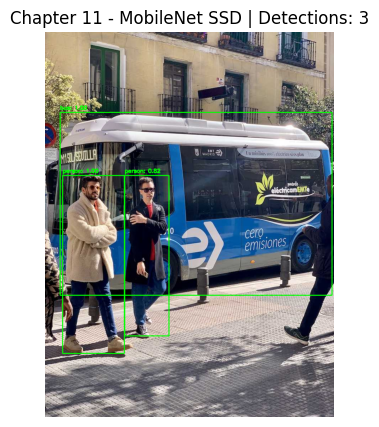

In [15]:
CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair',
           'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa',
           'train', 'tvmonitor']

ssd_net = cv2.dnn.readNetFromCaffe(
    str(MODELS_DIR / 'mobilenet_ssd_deploy.prototxt'),
    str(MODELS_DIR / 'mobilenet_iter_73000.caffemodel')
)

img_ssd = cv2.imread(str(DATA_DIR / 'bus.jpg'))
(h, w) = img_ssd.shape[:2]
blob = cv2.dnn.blobFromImage(cv2.resize(img_ssd, (300, 300)), 0.007843, (300, 300), 127.5)
ssd_net.setInput(blob)
detections = ssd_net.forward()

boxes, labels = [], []
for i in range(detections.shape[2]):
    confidence = float(detections[0, 0, i, 2])
    if confidence > 0.5:
        idx = int(detections[0, 0, i, 1])
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        x1, y1, x2, y2 = box.astype('int')
        boxes.append((x1, y1, x2, y2))
        labels.append(f"{CLASSES[idx]}: {confidence:.2f}")

ssd_out = draw_boxes(img_ssd, boxes, color=(0, 255, 0), labels=labels)
show_image(ssd_out, title=f'Chapter 11 - MobileNet SSD | Detections: {len(boxes)}')


Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 318ms
Prepared 4 packages in 1.95s
Installed 4 packages in 249ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.7s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (5.3s)
Resul

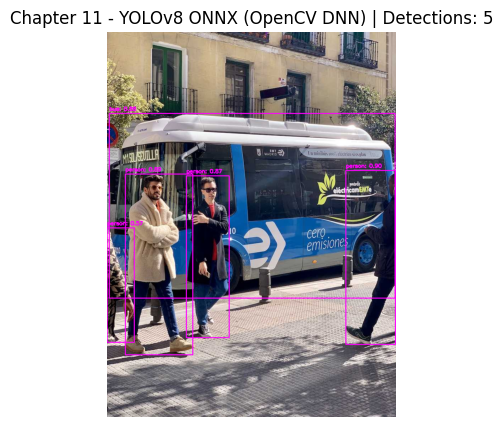

In [16]:
onnx_path = Path(yolo_model.export(format='onnx', opset=12, simplify=True, imgsz=640, dynamic=False, verbose=False))
print('Exported ONNX:', onnx_path)

onnx_net = cv2.dnn.readNetFromONNX(str(onnx_path))


def yolo_v8_onnx_opencv_detect(image_bgr, net, class_names, conf_thres=0.35, iou_thres=0.45):
    h0, w0 = image_bgr.shape[:2]
    inp = cv2.resize(image_bgr, (640, 640))
    blob = cv2.dnn.blobFromImage(inp, 1/255.0, (640, 640), swapRB=True, crop=False)
    net.setInput(blob)
    pred = net.forward()
    pred = np.squeeze(pred)

    if pred.shape[0] < pred.shape[1]:
        pred = pred.T

    boxes, scores, class_ids = [], [], []
    for det in pred:
        cx, cy, w, h = det[:4]
        cls_scores = det[4:]
        cls_id = int(np.argmax(cls_scores))
        conf = float(cls_scores[cls_id])
        if conf < conf_thres:
            continue

        x1 = int((cx - w/2) * w0 / 640)
        y1 = int((cy - h/2) * h0 / 640)
        bw = int(w * w0 / 640)
        bh = int(h * h0 / 640)

        boxes.append([x1, y1, bw, bh])
        scores.append(conf)
        class_ids.append(cls_id)

    idxs = cv2.dnn.NMSBoxes(boxes, scores, conf_thres, iou_thres)
    out_boxes, out_labels = [], []
    if len(idxs) > 0:
        for i in idxs.flatten():
            x, y, bw, bh = boxes[i]
            out_boxes.append((x, y, x + bw, y + bh))
            out_labels.append(f"{class_names[class_ids[i]]}: {scores[i]:.2f}")

    return out_boxes, out_labels


class_names = [yolo_model.names[i] for i in range(len(yolo_model.names))]
img_onnx = cv2.imread(str(DATA_DIR / 'bus.jpg'))
boxes_onnx, labels_onnx = yolo_v8_onnx_opencv_detect(img_onnx, onnx_net, class_names)

onnx_out = draw_boxes(img_onnx, boxes_onnx, color=(255, 0, 255), labels=labels_onnx)
show_image(onnx_out, title=f'Chapter 11 - YOLOv8 ONNX (OpenCV DNN) | Detections: {len(boxes_onnx)}')


  detector  frames  elapsed_sec    fps
0     YOLO      30         0.31  96.89
1      SSD      30         1.79  16.78


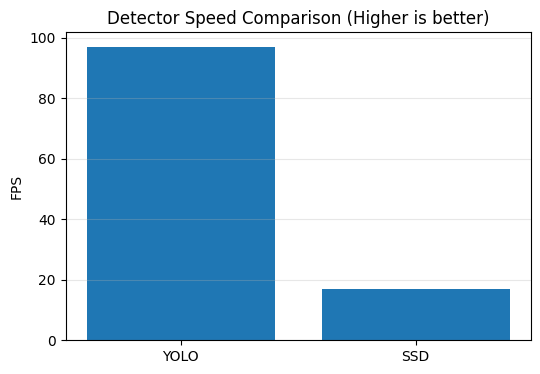

In [17]:
def benchmark_video_detector(video_path, detector_name, max_frames=80):
    cap = cv2.VideoCapture(str(video_path))
    n = 0
    t0 = time.time()

    while n < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        if detector_name == 'yolo':
            _ = yolo_model.predict(source=frame, conf=0.4, verbose=False)
        elif detector_name == 'ssd':
            blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 0.007843, (300, 300), 127.5)
            ssd_net.setInput(blob)
            _ = ssd_net.forward()
        else:
            raise ValueError('Unknown detector')

        n += 1

    cap.release()
    elapsed = max(time.time() - t0, 1e-6)
    fps = n / elapsed
    return n, elapsed, fps

rows = []
for name in ['yolo', 'ssd']:
    n, elapsed, fps = benchmark_video_detector(DATA_DIR / 'traffic.mp4', name, max_frames=80)
    rows.append({'detector': name.upper(), 'frames': n, 'elapsed_sec': round(elapsed, 2), 'fps': round(fps, 2)})

df_bench = pd.DataFrame(rows)
print(df_bench)

plt.figure(figsize=(6, 4))
plt.bar(df_bench['detector'], df_bench['fps'])
plt.title('Detector Speed Comparison (Higher is better)')
plt.ylabel('FPS')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Chapter 12: Facial Recognition & Landmark Detection (OpenCV DNN + Dlib)


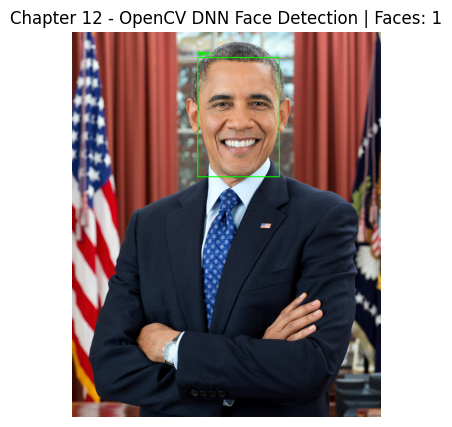

In [18]:
face_net = cv2.dnn.readNetFromCaffe(
    str(MODELS_DIR / 'face_deploy.prototxt'),
    str(MODELS_DIR / 'res10_300x300_ssd_iter_140000.caffemodel')
)

img_face = cv2.imread(str(DATA_DIR / 'obama.jpg'))
(h, w) = img_face.shape[:2]
blob = cv2.dnn.blobFromImage(img_face, 1.0, (300, 300), (104.0, 177.0, 123.0))
face_net.setInput(blob)
detections = face_net.forward()

face_boxes = []
for i in range(detections.shape[2]):
    conf = float(detections[0, 0, i, 2])
    if conf > 0.5:
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        x1, y1, x2, y2 = box.astype(int)
        face_boxes.append((x1, y1, x2, y2))

img_face_det = draw_boxes(img_face, face_boxes, color=(0, 255, 0), labels=[f'face {i+1}' for i in range(len(face_boxes))])
show_image(img_face_det, title=f'Chapter 12 - OpenCV DNN Face Detection | Faces: {len(face_boxes)}')


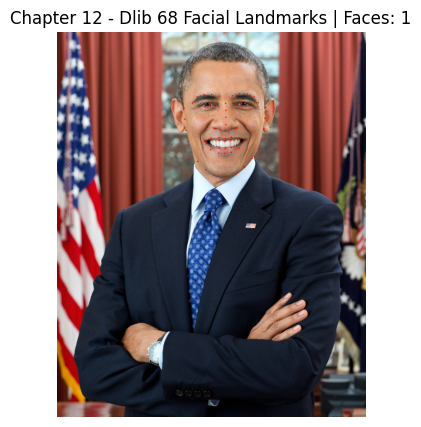

In [19]:
predictor = dlib.shape_predictor(str(MODELS_DIR / 'shape_predictor_68_face_landmarks.dat'))
detector = dlib.get_frontal_face_detector()

img_lm = cv2.imread(str(DATA_DIR / 'obama.jpg'))
gray_lm = cv2.cvtColor(img_lm, cv2.COLOR_BGR2GRAY)
rects = detector(gray_lm, 1)

img_lm_out = img_lm.copy()
for rect in rects:
    shape = predictor(gray_lm, rect)
    shape = face_utils.shape_to_np(shape)
    for (x, y) in shape:
        cv2.circle(img_lm_out, (x, y), 2, (0, 0, 255), -1)

show_image(img_lm_out, title=f'Chapter 12 - Dlib 68 Facial Landmarks | Faces: {len(rects)}')


In [20]:
known_image = face_recognition.load_image_file(str(DATA_DIR / 'obama.jpg'))
test_same = face_recognition.load_image_file(str(DATA_DIR / 'obama2.jpg'))
test_diff = face_recognition.load_image_file(str(DATA_DIR / 'biden.jpg'))

known_encoding = face_recognition.face_encodings(known_image)[0]
same_encoding = face_recognition.face_encodings(test_same)[0]
diff_encoding = face_recognition.face_encodings(test_diff)[0]

same_match = face_recognition.compare_faces([known_encoding], same_encoding)[0]
diff_match = face_recognition.compare_faces([known_encoding], diff_encoding)[0]

same_dist = face_recognition.face_distance([known_encoding], same_encoding)[0]
diff_dist = face_recognition.face_distance([known_encoding], diff_encoding)[0]

df_rec = pd.DataFrame([
    {'comparison': 'obama vs obama2', 'match': bool(same_match), 'distance': float(same_dist)},
    {'comparison': 'obama vs biden', 'match': bool(diff_match), 'distance': float(diff_dist)},
])
print(df_rec)


        comparison  match  distance
0  obama vs obama2   True  0.345735
1   obama vs biden  False  0.840175


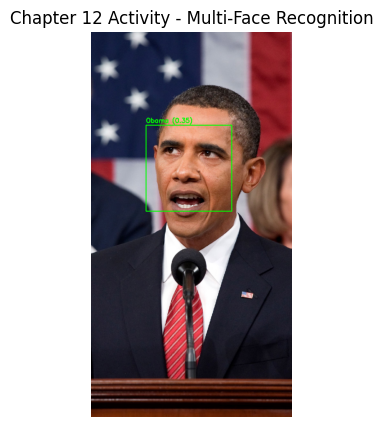

In [21]:
# Suggested activity: mini multi-face recognition database
known_db = {
    'Obama': str(DATA_DIR / 'obama.jpg'),
    'Biden': str(DATA_DIR / 'biden.jpg'),
}

known_names, known_encodings = [], []
for name, path in known_db.items():
    img = face_recognition.load_image_file(path)
    encs = face_recognition.face_encodings(img)
    if len(encs) > 0:
        known_names.append(name)
        known_encodings.append(encs[0])

test_img = cv2.imread(str(DATA_DIR / 'obama2.jpg'))
test_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
locs = face_recognition.face_locations(test_rgb)
encs = face_recognition.face_encodings(test_rgb, locs)

out = test_img.copy()
for (top, right, bottom, left), enc in zip(locs, encs):
    dists = face_recognition.face_distance(known_encodings, enc)
    best_idx = int(np.argmin(dists))
    best_name = known_names[best_idx]
    best_dist = dists[best_idx]
    label = f'{best_name} ({best_dist:.2f})' if best_dist < 0.55 else f'Unknown ({best_dist:.2f})'

    cv2.rectangle(out, (left, top), (right, bottom), (0, 255, 0), 2)
    cv2.putText(out, label, (left, max(top - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)

show_image(out, title='Chapter 12 Activity - Multi-Face Recognition')


In [22]:
print('=== Experimental Observations (Auto Summary) ===')
print(f'1) Chapter 9 (Haar): Faces detected = {len(face_boxes)}')
print('2) Chapter 9 (HOG): winStride/scale tune speed-vs-detection trade-off.')
print('3) Chapter 11: YOLOv8 tends to be more accurate; SSD is often lighter in deployment.')
print(df_bench.to_string(index=False))
print('4) Chapter 12: Same identity -> lower embedding distance, different identity -> higher distance.')
print(df_rec.to_string(index=False))


=== Experimental Observations (Auto Summary) ===
1) Chapter 9 (Haar): Faces detected = 1
2) Chapter 9 (HOG): winStride/scale tune speed-vs-detection trade-off.
3) Chapter 11: YOLOv8 tends to be more accurate; SSD is often lighter in deployment.
detector  frames  elapsed_sec   fps
    YOLO      30         0.31 96.89
     SSD      30         1.79 16.78
4) Chapter 12: Same identity -> lower embedding distance, different identity -> higher distance.
     comparison  match  distance
obama vs obama2   True  0.345735
 obama vs biden  False  0.840175
